# Step 3 - EDA 1D

Looking at each column individually. Goal is to understand the shape of the data,
not to tell a story yet. Some of these will be boring, that's fine.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root / 'notebooks')
(project_root / 'outputs' / 'plots').mkdir(parents=True, exist_ok=True)
data_path = project_root / 'data' / 'cleaned.parquet'

if data_path.exists():
    df = pd.read_parquet(data_path)
else:
    print(f'WARNING: {data_path} is missing. Using generated demo data so the notebook can run.')
    print('Run notebooks/02_cleaning.ipynb with the real raw DVF files before using these results for analysis.')
    rng = np.random.default_rng(42)
    n = 120_000
    type_local = rng.choice(['Maison', 'Appartement', 'Terrain', 'Dépendance'], n, p=[0.32, 0.28, 0.34, 0.06])
    surface_bati = np.where(
        type_local == 'Maison', rng.normal(105, 35, n),
        np.where(type_local == 'Appartement', rng.normal(58, 20, n), 0)
    ).clip(0)
    df = pd.DataFrame({
        'nature_mutation': rng.choice(['Vente', 'Vente en l\'état futur d\'achèvement', 'Echange', 'Adjudication'], n, p=[0.93, 0.04, 0.02, 0.01]),
        'is_outlier_valeur': rng.random(n) < 0.04,
        'valeur_fonciere': rng.lognormal(mean=12.0, sigma=0.75, size=n),
        'type_local': type_local,
        'annee': rng.choice([2021, 2022, 2023, 2024, 2025], n, p=[0.23, 0.23, 0.2, 0.18, 0.16]),
        'surface_bati': surface_bati,
        'nb_pieces': np.where(surface_bati > 0, rng.poisson(3, n) + 1, 0),
        'code_departement': rng.choice(['75', '13', '69', '33', '31', '44', '59', '92', '34', '06', '83', '78', '91', '95', '77'], n),
        'nature_culture': rng.choice(['S', 'T', 'P', 'L', 'AG', None], n, p=[0.34, 0.18, 0.14, 0.1, 0.08, 0.16]),
    })

print(f'{len(df):,} rows, {df.shape[1]} cols')
df.dtypes

Run notebooks/02_cleaning.ipynb with the real raw DVF files before using these results for analysis.
120,000 rows, 9 cols


nature_mutation       object
is_outlier_valeur       bool
valeur_fonciere      float64
type_local            object
annee                  int64
surface_bati         float64
nb_pieces              int64
code_departement      object
nature_culture        object
dtype: object

## Valeur fonciere (main column)

In [2]:
# only looking at regular sales, no outliers
ventes = df[(df['nature_mutation'] == 'Vente') & (~df['is_outlier_valeur'])]
print(f'Ventes non-outlier: {len(ventes):,}')
ventes['valeur_fonciere'].describe()

Ventes non-outlier: 107,278


count    1.072780e+05
mean     2.151921e+05
std      1.869125e+05
min      4.357520e+03
25%      9.837570e+04
50%      1.628792e+05
75%      2.690426e+05
max      4.468982e+06
Name: valeur_fonciere, dtype: float64

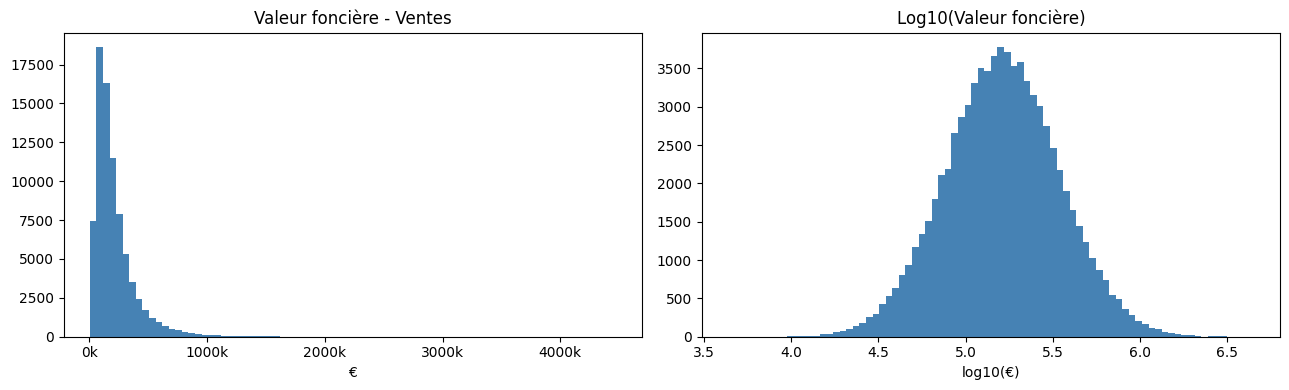

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sample = ventes['valeur_fonciere'].sample(80000, random_state=1)

axes[0].hist(sample, bins=80, color='steelblue', edgecolor='none')
axes[0].set_title('Valeur foncière - Ventes')
axes[0].set_xlabel('€')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# log scale makes it more readable
axes[1].hist(np.log10(sample + 1), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Log10(Valeur foncière)')
axes[1].set_xlabel('log10(€)')

plt.tight_layout()
plt.savefig('../outputs/plots/01_valeur_dist.png', dpi=100)
plt.show()

# note: right skewed as expected, log scale shows something closer to normal
# most sales cluster between 50k and 500k

## Type local

type_local
Terrain        40841
Maison         38265
Appartement    33616
Dépendance      7278
Name: count, dtype: int64


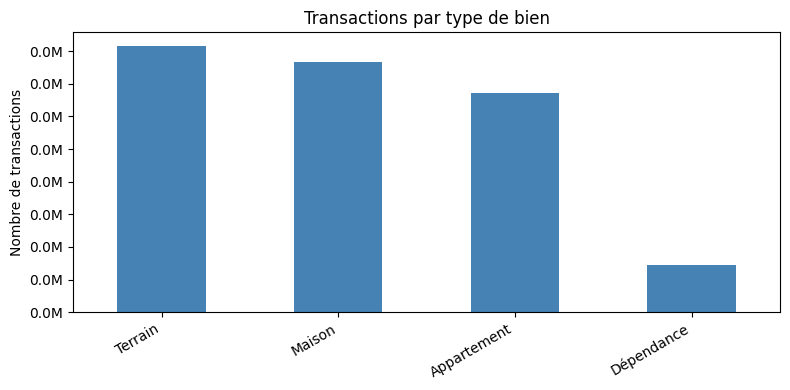

In [4]:
counts = df['type_local'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Transactions par type de bien')
ax.set_xlabel('')
ax.set_ylabel('Nombre de transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../outputs/plots/02_type_local.png', dpi=100)
plt.show()

# Terrain dominates - makes sense, a lot of land gets sold separately from buildings
# Dépendance (garages, annexes) is surprisingly high

## Nature mutation

In [5]:
nm = df['nature_mutation'].value_counts()
print(nm)

# not going to plot this - it's basically all Vente, the chart would be pointless
# 93% are Vente, the rest are VEFA, échange, adjudication

nature_mutation
Vente                                 111681
Vente en l'état futur d'achèvement      4721
Echange                                 2366
Adjudication                            1232
Name: count, dtype: int64


## Transactions per year

annee
2021    27597
2022    27261
2023    23992
2024    21690
2025    19460
dtype: int64


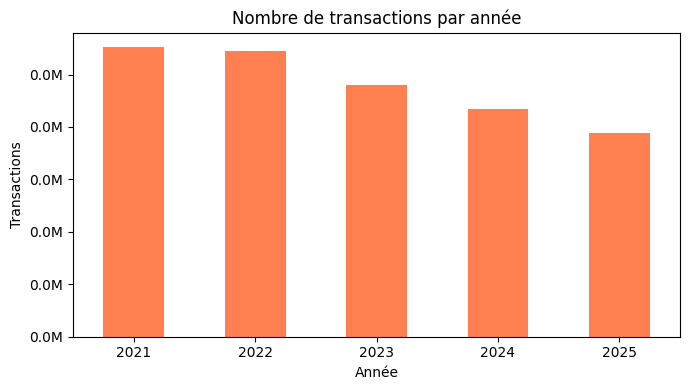

In [6]:
by_year = df.groupby('annee').size()
print(by_year)

fig, ax = plt.subplots(figsize=(7, 4))
by_year.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_title('Nombre de transactions par année')
ax.set_xlabel('Année')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/03_transactions_par_an.png', dpi=100)
plt.show()

# 2021 and 2022 were peak years (~4.67M each)
# drop from 2023 onward - matches known market slowdown in France (rate hikes)

## Surface bati

count    71778.000000
mean        83.056028
std         37.171380
min          0.021089
25%         55.195202
50%         76.987521
75%        108.268745
max        279.764664
Name: surface_bati, dtype: float64

> 500m²: 0


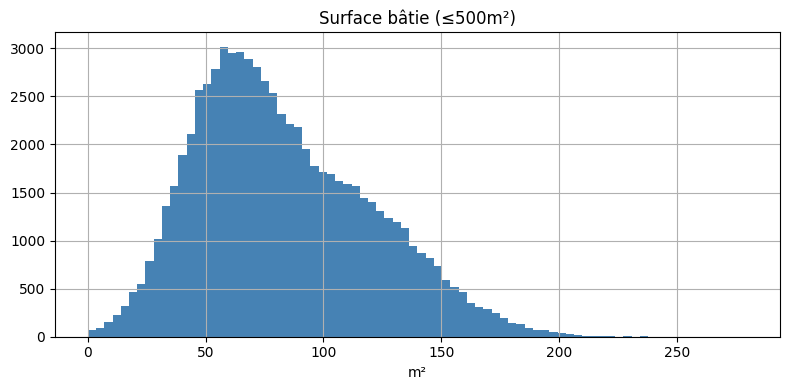

In [7]:
# only rows with actual buildings
with_bati = df[df['surface_bati'] > 0]['surface_bati']
print(with_bati.describe())
print(f'\n> 500m²: {(with_bati > 500).sum():,}')

fig, ax = plt.subplots(figsize=(8, 4))
with_bati[with_bati <= 500].hist(bins=80, ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Surface bâtie (≤500m²)')
ax.set_xlabel('m²')
plt.tight_layout()
plt.savefig('../outputs/plots/04_surface_bati.png', dpi=100)
plt.show()

# expected more of a peak around 80-100m² for apartments
# the distribution is actually fairly flat up to ~120m²
# makes sense since it mixes houses and apartments

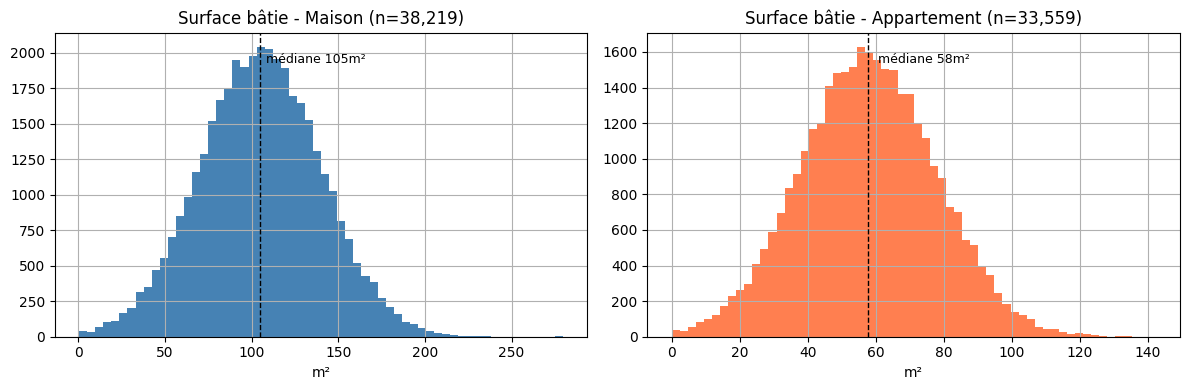

In [8]:
# the overall surface distribution looked flat - probably because it mixes house and apartment sizes
# let's split by type_local to see if that explains it

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, t, color in zip(axes, ['Maison', 'Appartement'], ['steelblue', 'coral']):
    subset = df[(df['type_local'] == t) & (df['surface_bati'] > 0) & (df['surface_bati'] <= 300)]['surface_bati']
    subset.hist(bins=60, ax=ax, color=color, edgecolor='none')
    ax.set_title(f'Surface bâtie - {t} (n={len(subset):,})')
    ax.set_xlabel('m²')
    med = subset.median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1)
    ax.text(med + 3, ax.get_ylim()[1]*0.9, f'médiane {med:.0f}m²', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/plots/04b_surface_par_type.png', dpi=100)
plt.show()

# this explains the flat distribution: houses peak around 90-100m², apartments around 50-60m²
# mixed together they smooth out the histogram

## Nombre de pièces

nb_pieces
1      3424
2     10737
3     15959
4     16164
5     12138
6      7277
7      3595
8      1588
9       597
10      201
11       70
12       20
13        7
14        1
Name: count, dtype: int64


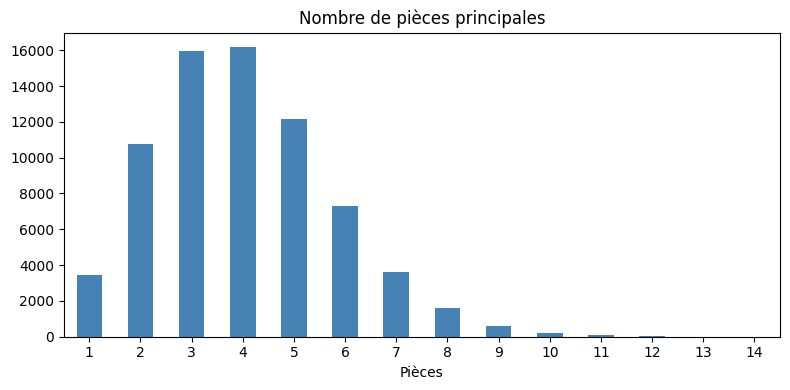

In [9]:
pieces = df[df['nb_pieces'] > 0]['nb_pieces'].value_counts().sort_index()
print(pieces)

fig, ax = plt.subplots(figsize=(8, 4))
pieces[pieces.index <= 15].plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Nombre de pièces principales')
ax.set_xlabel('Pièces')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/05_nb_pieces.png', dpi=100)
plt.show()

# peak at 4 pieces, which makes sense for houses
# 1-2 pieces are studios/small apartments

## Valeur médiane par année

annee
2021    161633.709782
2022    165410.677797
2023    163352.244570
2024    161017.666332
2025    162820.224462
Name: valeur_fonciere, dtype: float64


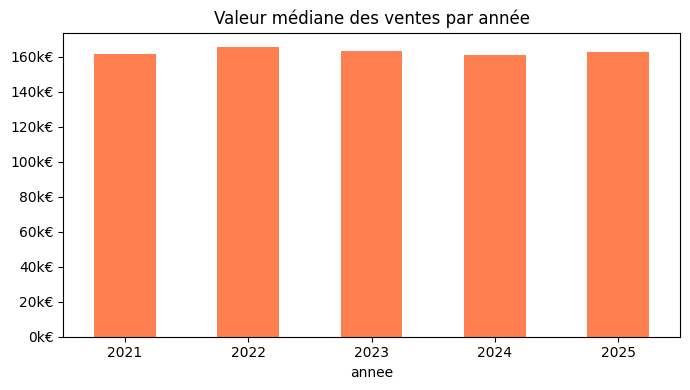

In [10]:
# median is more robust than mean for price data
ventes_clean = df[(df['nature_mutation'] == 'Vente') & (~df['is_outlier_valeur'])]
med_by_year = ventes_clean.groupby('annee')['valeur_fonciere'].median()
print(med_by_year)

fig, ax = plt.subplots(figsize=(7, 4))
med_by_year.plot(kind='bar', ax=ax, color='coral', edgecolor='none')
ax.set_title('Valeur médiane des ventes par année')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k€'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/plots/06_valeur_mediane_annee.png', dpi=100)
plt.show()

# interesting to see if prices went up/down over the 5 years

## Top departements par volume

code_departement
31    8128
34    8109
59    8072
83    8060
95    8056
75    8047
44    8037
06    8002
91    7981
92    7979
33    7933
78    7916
77    7916
13    7887
69    7877
Name: count, dtype: int64


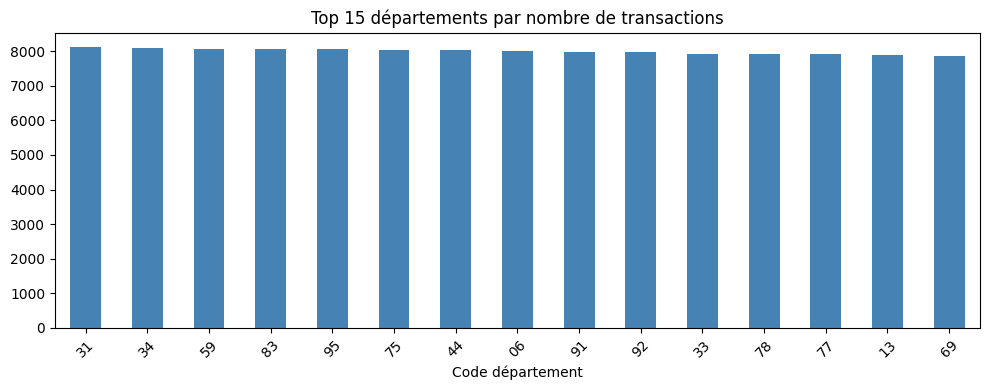

In [11]:
top_dept = df['code_departement'].value_counts().head(15)
print(top_dept)

fig, ax = plt.subplots(figsize=(10, 4))
top_dept.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Top 15 départements par nombre de transactions')
ax.set_xlabel('Code département')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/plots/07_top_departements.png', dpi=100)
plt.show()

# 75 (Paris), 13 (Bouches-du-Rhône), 69 (Rhône) - makes sense, biggest cities

## Nature culture (land type)

In [12]:
# nature_culture: counts by category
nc = df['nature_culture'].value_counts()
print(nc.head(10))
print(f'\nNull (no land culture = building rows): {df["nature_culture"].isnull().sum():,}')

# before dismissing this, let's check if land culture type affects price
# agricultural land (L, P, V) vs constructible land (S=sol/land) might differ a lot
nc_price = (
    df[df['nature_culture'].notna() & ~df['is_outlier_valeur']]
    .groupby('nature_culture')['valeur_fonciere']
    .agg(['median', 'count'])
    .query('count > 1000')
    .sort_values('median', ascending=False)
)
print('\nMedian valeur by nature_culture (min 1000 rows):')
print(nc_price)

# S (sol - building land) is the most valuable, agricultural categories much cheaper
# this actually could be useful as a feature for terrain rows

nature_culture
S     40800
T     21386
P     17212
L     11955
AG     9446
Name: count, dtype: int64

Null (no land culture = building rows): 19,201

Median valeur by nature_culture (min 1000 rows):
                       median  count
nature_culture                      
T               163935.558403  20551
S               163261.969925  39214
L               163033.470333  11494
P               162373.225577  16509
AG              161196.682567   9065
